# Retail-Sales-Customer-Analytics-Dashboard

## 1. Project Overview

This project focuses on analyzing customer purchasing behavior, product performance, and revenue trends using the Online Retail II dataset. The analysis aims to identify meaningful business insights that can help an e-commerce company improve customer retention, optimize sales strategies, and increase overall revenue.

The project includes:

data cleaning
exploratory data analysis
customer analytics
revenue analysis
statistical analysis
business insight generation
dashboard-ready reporting

## 2. Problem Statement

E-commerce businesses generate large volumes of transactional data every day. However, raw data alone does not help businesses make decisions unless it is properly analyzed.

The company wants to understand:

customer purchasing patterns
sales and revenue trends
high-performing products
customer retention behavior
cancellation and return patterns

The challenge is to convert raw transactional data into meaningful business insights that support better decision-making and business growth.

## 3. Project Objective

The main objective of this project is to analyze customer transactions and revenue data to identify important business patterns, customer behavior trends, and sales opportunities.

This project aims to:

analyze customer purchasing behavior
identify top-performing products and customers
study revenue and sales trends
understand customer retention and repeat purchases
detect cancellations and return behavior
generate business-driven insights for decision-making

## 4. Business Goals

The business goals of this project are:

Increase revenue through better sales analysis
Improve customer retention and loyalty
Identify high-value customers
Optimize product and inventory planning
Understand country-wise sales performance
Reduce cancellations and return-related losses
Support data-driven business decisions

## 5. Expected Outcome

At the end of this project, meaningful business insights will be generated regarding:

customer behavior
revenue growth opportunities
product performance
customer retention
business optimization strategies

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading a CSV File and then creating a DataFrame

In [2]:
df = pd.read_excel(r"C:\Users\aishw\OneDrive\Desktop\New folder (2)\OnlineRetail_II_Dataset\online_retail_II.xlsx")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


## Task 1 - Understanding the Dataset

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(525461, 8)

#### Observation 1    :  Dataset contains 525461 million records and 8 columns.

In [5]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

#### Observation 2    :  Columns include Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country'

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


#### Observation 3    :  Some columns are categorical while some are numerical.
#### Observation 4    :  A significant number of transactions do not contain customer identification information. This may affect customer-level analysis such as retention, segmentation, &     repeat purchase analysis.

In [7]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


#### Observation 5 :    The Quantity column contains negative values, which may represent cancelled orders, returned products, or refund transactions.
#### Observation 6 :    Most customer purchases involve small quantities, while a few transactions contain extremely large quantities. This indicates the presence of bulk orders or outlier transactions.
#### Observation 7 :    The large difference between the average quantity and median quantity suggests that the dataset is positively skewed, where a small number of high-volume purchases significantly influence the overall average.
#### Observation 8 :    The Price column also contains negative values, which may indicate refund adjustments, pricing errors, or return-related transactions that require further investigation during data cleaning.
#### Observation 9 :    The dataset contains very high price values and quantity values, indicating the presence of potential outliers that may impact revenue analysis and statistical calculations.
#### Observation 10 :   The transaction records range from December 2009 to December 2010, making the dataset suitable for monthly trend analysis, seasonal analysis, and time-based customer behavior analysis.

## Task 2 - Data Cleaning

### Checking Missing Values

In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

#### Observation 11 :   The Customer ID column contains a large number of missing values, which may limit customer-level analyses such as customer retention, repeat purchase tracking, and customer segmentation.
#### Observation 14 :    Although Customer ID values are missing for many transactions, these records may still remain useful for revenue analysis and sales trend analysis since quantity and price information are available.
#### Observation 15 :   The Description column contains relatively fewer missing values compared to the total dataset size, indicating a limited impact on overall product-level analysis.

### STEP 1 — Missing Value Analysis

In [9]:
df[df['Description'].isnull()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524730,538141,22218,NaN,2,2010-12-09 15:58:00,0.0,NaN,United Kingdom
524731,538143,84534B,NaN,1,2010-12-09 15:58:00,0.0,NaN,United Kingdom
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.0,NaN,United Kingdom


#### Observation 16 :   Investigation of missing Description records shows that many of these rows also contain missing Customer IDs, zero prices, and abnormal quantity values, indicating incomplete or non-meaningful transactional records.
#### Observation 17 :   Since the number of affected rows is very small compared to the total dataset size, removing these records is unlikely to significantly impact overall business analysis.

In [10]:
df = df.dropna(subset=['Description'])

In [11]:
df.isnull().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    104999
Country             0
dtype: int64

#### Observation 18 :   After cleaning the Description column, Customer ID remains the only column containing missing values, indicating that the dataset is now structurally cleaner for further preprocessing and analysis.

### STEP 1 — Duplicate Analysis

In [12]:
df.duplicated().sum()

6865

In [13]:
df[df.duplicated()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
523258,538035,20728,LUNCH BAG CARS BLUE,3,2010-12-09 13:03:00,1.65,16065.0,United Kingdom
523356,538051,22659,LUNCH BOX I LOVE LONDON,2,2010-12-09 13:24:00,1.95,18041.0,United Kingdom
525170,538155,21907,I'M ON HOLIDAY METAL SIGN,1,2010-12-09 16:52:00,2.10,16907.0,United Kingdom
525293,538166,21915,RED HARMONICA IN BOX,5,2010-12-09 18:09:00,1.25,17965.0,United Kingdom


#### Observation 19 :   Since the duplicate rows do not represent unique business transactions, removing them will improve data accuracy and analytical reliability.

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

0

### Step 3 : Invalid Transaction Analysis

Investigating Negative Quantity Transactions

In [16]:
df[df['Quantity']<0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


#### Observation 20 :   The dataset contains 10,475 transactions with negative quantity values.
#### Observation 21 :   Most negative quantity transactions contain invoice numbers starting with “C”, indicating cancelled or returned orders rather than invalid data entries.
#### Observation 22 :   Negative quantity records represent important business events such as product returns, cancellations, and refunds, making them valuable for return behavior analysis.
#### Observation 23 :   Some negative quantity records contain zero prices and missing customer IDs, suggesting the presence of internal adjustments or incomplete transactional entries.

### OUR PROJECT STRATEGY 

We will separate cancellation transactions
keep them for return analysis and 
use only positive quantity transactions for main sales/revenue analysis

### Create cancellation dataset:

In [17]:
cancelled_df = df[df['Quantity']<0]

#### Create successful sales dataset:

In [18]:
df = df[df['Quantity']>0]

Because for:

revenue trends
customer purchases
product demand

positive sales transactions are more appropriate.

While cancellations can be analyzed separately later.

Investigating Zero or Negative Price Transactions

In [19]:
df[df['Price']<=0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
5904,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
...,...,...,...,...,...,...,...,...
517328,537534,20652,BLUE POLKADOT LUGGAGE TAG,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
517329,537534,20615,BLUE POLKADOT PASSPORT COVER,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
518589,537639,22734,amazon,30,2010-12-07 15:29:00,0.0,NaN,United Kingdom
518595,537640,21232,STRAWBERRY CERAMIC TRINKET BOX,1,2010-12-07 15:31:00,0.0,NaN,United Kingdom


#### Observation 24 :   The dataset contains 462 transactions with zero or non-positive price values.
#### Observation 25 :   Many zero-price records appear to represent internal adjustments, postage entries, promotional items, or incomplete transactions rather than actual revenue-generating sales.
#### Observation 26 :   Since these records contribute no sales revenue and may distort pricing and profitability analysis, they are not suitable for main revenue analytics.

In [20]:
df = df[df['Price']>0]

In [21]:
df[df['Price']<0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


Now main dataset contains:

valid product descriptions,
no duplicate rows,
only positive quantities,
only valid positive prices.

### Step 4 : Outlier Analysis

#### Quantity Outlier Analysis

In [22]:
df['Quantity'].describe()

count    504731.000000
mean         11.516923
std          87.337497
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64

#### Observation 27 :   Most transactions involve small purchase quantities, as 75% of transactions contain 12 or fewer items.
#### Observation 28 :   The maximum quantity value is extremely high compared to the typical transaction range, indicating the presence of bulk purchases or extreme outlier transactions.
#### Observation 29 :   The large difference between the median quantity (3) and maximum quantity (19,152) suggests that the Quantity column remains highly right-skewed even after cleaning invalid transactions.
#### Observation 30 :   The high standard deviation indicates wide variation in customer purchasing behavior, where a small number of bulk orders significantly increase the spread of the data.

### VISUALIZE OUTLIERS by using Box Plot

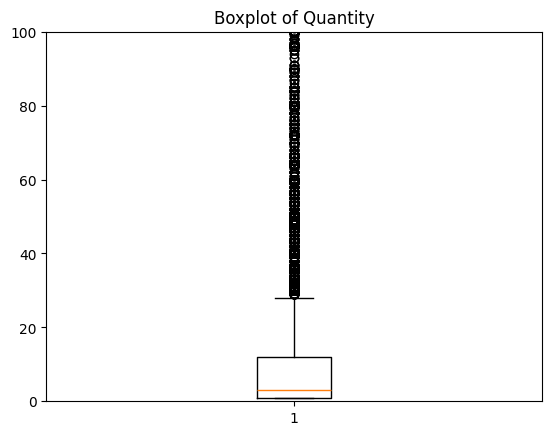

In [23]:
plt.boxplot(df['Quantity'])
plt.title('Boxplot of Quantity')
#plt.ylabel('Quantity')
plt.ylim(0,100)
plt.show()

#### Observation 31 :we will KEEP quantity outliers.
Because:

they may represent real bulk orders
revenue analysis should include high-value purchases
customer behavior naturally varies in retail business

Price Outlier Analysis

In [24]:
df['Price'].describe()

count    504731.000000
mean          4.274692
std          64.093333
min           0.001000
25%           1.250000
50%           2.100000
75%           4.210000
max       25111.090000
Name: Price, dtype: float64

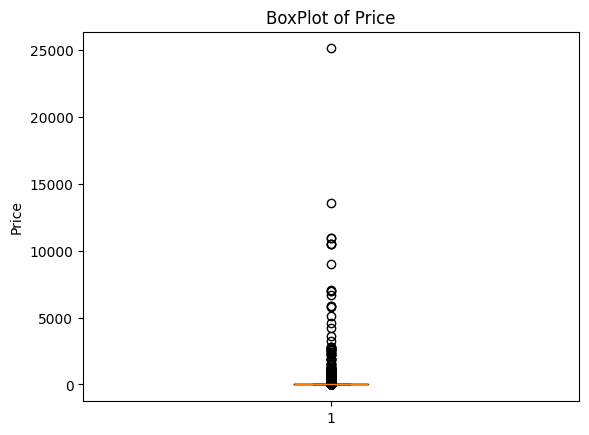

In [25]:
plt.boxplot(df['Price'])
plt.ylabel('Price')
plt.title('BoxPlot of Price')
plt.show()

Zoomed verson just to see claearly

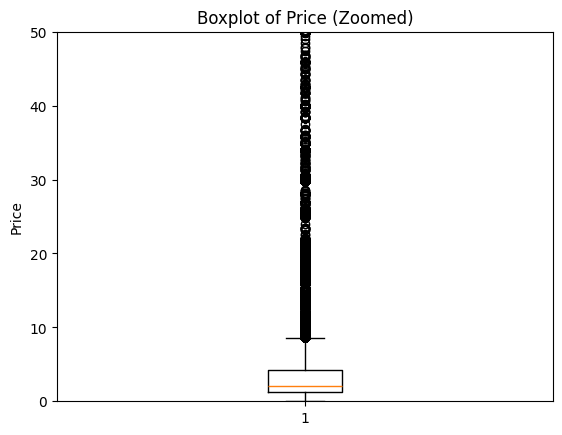

In [26]:
plt.boxplot(df['Price'])
plt.ylim(0,50)
plt.title('Boxplot of Price (Zoomed)')
plt.ylabel('Price')
plt.show()

#### Observation 32 :    The majority of product prices are concentrated within a low-price range, indicating that the business primarily sells affordable retail products.
#### Observation 33 :    Several high-price outliers exist beyond the upper whisker, representing premium-priced or unusual product transactions.
#### Observation 34 :   The Price distribution remains positively skewed, where a small number of expensive products significantly differ from normal pricing behavior.

#### we will KEEP price outliers.
Because they may represent genuine premium products
removing them may lose important revenue insights
retail businesses naturally contain varied pricing ranges

## Task 3 - Feature Engineering

#### Creating Revenue Column

In [27]:
df['Revenue'] = df['Quantity']*df['Price']

In [28]:
df.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0


#### Creating Year Column

In [29]:
df['Year'] = df['InvoiceDate'].dt.year

#### Creating Month Column

In [30]:
df['Month'] = df['InvoiceDate'].dt.month

#### Creating Month Name Column

In [31]:
df['MonthName'] = df['InvoiceDate'].dt.month_name()

#### Creating Day Column

In [32]:
df['Day'] = df['InvoiceDate'].dt.day

#### Creating Day Name Column

In [33]:
df['DayName'] = df['InvoiceDate'].dt.day_name()

#### Creating Hour Column

In [34]:
df['Hour'] = df['InvoiceDate'].dt.hour

#### Creating YearMonth Column

In [35]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

#### Creating Quarter Column

In [145]:
df['Quarter'] = 'Q' + df['InvoiceDate'].dt.quarter.astype(str)

In [146]:
df.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName,Day,DayName,Hour,YearMonth,Weekday,Quarter,Price_Category
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday,7,2009-12,Tuesday,Q4,Medium Price
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,7,2009-12,Tuesday,Q4,Medium Price


## Task 4 - Exploratory Data Analysis (EDA)

### Revenue Analysis(EDA)

In [37]:
df['Revenue'].describe()

count    504731.000000
mean         20.351705
std          91.510976
min           0.001000
25%           4.200000
50%          10.200000
75%          17.700000
max       25111.090000
Name: Revenue, dtype: float64

#### Observation 35 :   Most customer transactions generate relatively low revenue values, with 75% of transactions contributing less than 17.7 in revenue.
#### Observation 36 :   The average transaction revenue is almost double the median revenue, indicating the presence of high-value transactions influencing the distribution
#### Observation 37 :   The Revenue column is highly right-skewed, where a small number of transactions contribute exceptionally large revenue values compared to normal purchases.
#### Observation 37 :   The extremely high maximum revenue suggests the presence of bulk purchases, premium orders, or wholesale-type transactions within the business.
## "Most customers make small purchases while few customers generate very high revenue."

### Revenue Distribution Visualization

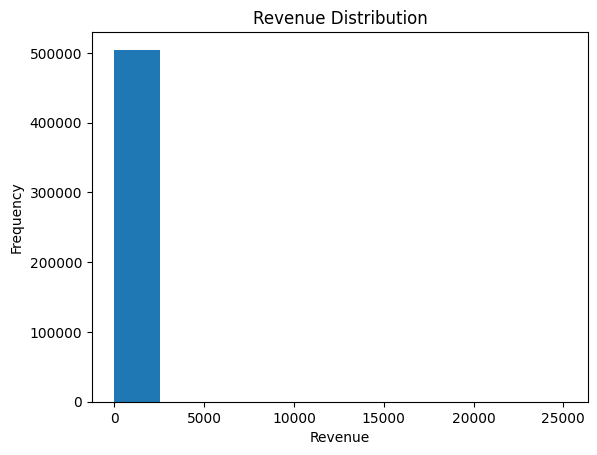

In [38]:
plt.hist(df['Revenue'])
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

### "Zoomed Revenue Distribution to see normal transactions clearly?"

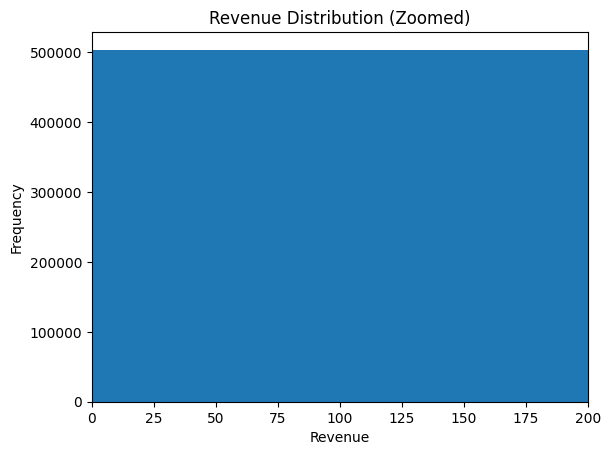

In [39]:
plt.hist(df['Revenue'],bins=50)
plt.xlim(0,200)
plt.title('Revenue Distribution (Zoomed)')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

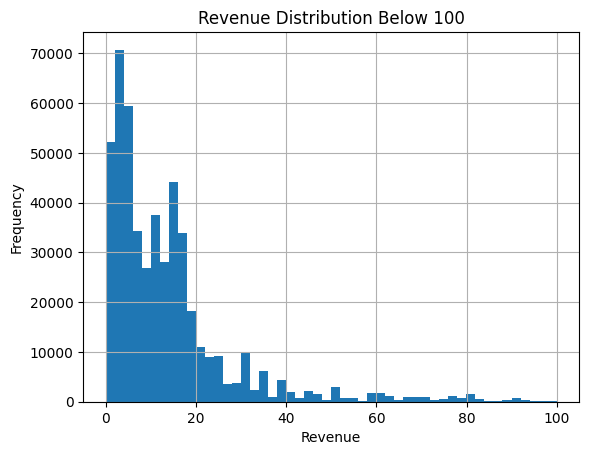

In [40]:
df[df['Revenue'] < 100]['Revenue'].hist(bins=50)

plt.title('Revenue Distribution Below 100')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

#### Observation 38 :   Most transactions are concentrated in lower revenue ranges, especially below 20 revenue units.
#### Observation 39 :   As transaction revenue increases, the number of purchases decreases significantly, indicating that high-value orders are relatively uncommon.
#### Observation 40 :   The business appears to generate a large portion of sales through frequent low-value purchases rather than a small number of expensive transactions alone.

"Most transactions had low revenue values, mainly below 20. As revenue increased, transaction frequency reduced significantly. This indicates that the business mainly depends on frequent small purchases while high-value purchases occur less often."

1. “Which months generate highest revenue?”

In [41]:
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()
monthly_revenue

YearMonth
2009-12     822483.950
2010-01     651155.112
2010-02     551878.296
2010-03     830915.261
2010-04     678875.252
2010-05     657705.500
2010-06     749537.310
2010-07     648810.270
2010-08     695251.910
2010-09     921696.991
2010-10    1161902.220
2010-11    1464293.142
2010-12     437631.020
Freq: M, Name: Revenue, dtype: float64

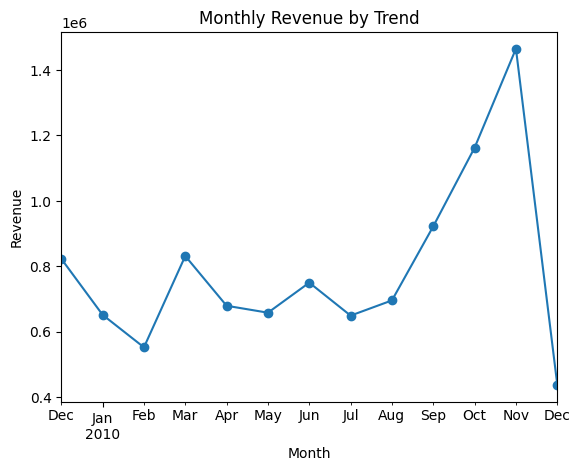

In [42]:
monthly_revenue.plot(kind='line',marker='o')
plt.title('Monthly Revenue by Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

2. Revenue Growth Analysis month over month growth

In [43]:
monthly_growth = monthly_revenue.pct_change() * 100
monthly_growth

YearMonth
2009-12          NaN
2010-01   -20.830660
2010-02   -15.246262
2010-03    50.561322
2010-04   -18.297896
2010-05    -3.118357
2010-06    13.962451
2010-07   -13.438563
2010-08     7.157969
2010-09    32.570221
2010-10    26.061193
2010-11    26.025505
2010-12   -70.113155
Freq: M, Name: Revenue, dtype: float64

In [44]:
### Monthly Revenue Trend - Observations
#### Observation 41 :   Revenue showed fluctuations during the early months of 2010, indicating varying monthly sales performance.
#### Observation 42 :   A strong increase in revenue was observed from September 2010 onwards, with sales peaking during October and November.
#### Observation 43 :   November 2010 recorded the highest monthly revenue, possibly due to festive season and holiday shopping demand.
#### Observation 44 :   Revenue appears to decline sharply in December 2010. However, the dataset contains only partial December data, so this does not necessarily indicate a real business decline.

### Business Insights
#### Business Insight 1 :    The business experiences higher customer demand during the final quarter, especially near festive and holiday seasons.
#### Business Insight 2 :   The company should focus more marketing, inventory, and sales planning during high-growth months to maximize revenue opportunities.

3. Which countries contribute the highest revenue?

In [45]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_revenue

Country
United Kingdom          8812685.403
EIRE                     380909.570
Netherlands              268784.350
Germany                  202025.391
France                   147103.140
Sweden                    53501.990
Denmark                   50906.850
Spain                     47568.650
Switzerland               43921.390
Australia                 31446.800
Channel Islands           24546.320
Belgium                   24537.580
Portugal                  24265.000
Norway                    23944.180
Italy                     15052.730
Greece                    14335.670
Austria                   13414.330
Cyprus                    11347.100
Japan                      9722.020
United Arab Emirates       9195.350
Hong Kong                  8202.520
Finland                    7379.460
Unspecified                6186.220
Malta                      5373.500
Lithuania                  4892.680
USA                        4786.470
Singapore                  4037.770
RSA                 

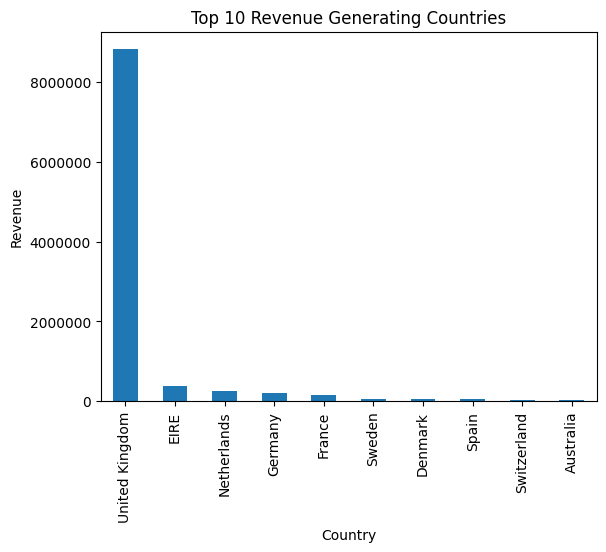

In [46]:
country_revenue.head(10).plot(kind='bar')
plt.title("Top 10 Revenue Generating Countries")
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Observations
#### Observation 45 :    The United Kingdom contributes the highest revenue by a very large margin compared to all other countries.
#### Observation 46 :   Most other countries generate comparatively lower revenue, showing that sales are heavily concentrated in a few major markets.

#### Business Insights
#### Business Insight 1 :   The business is heavily dominated by the United Kingdom market, while revenue contribution from other countries is comparatively much smaller.
#### Business Insight 2 :   There is potential for the business to improve sales in other countries through better marketing and international expansion strategies.

4. Which products generate the highest revenue?

In [47]:
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
product_revenue

Description
Manual                                262963.430
REGENCY CAKESTAND 3 TIER              169912.760
WHITE HANGING HEART T-LIGHT HOLDER    160345.630
DOTCOM POSTAGE                        116408.710
ASSORTED COLOUR BIRD ORNAMENT          72890.190
                                         ...    
SILICON CUBE 25W, BLUE                     0.420
PINK HEART CHRISTMAS DECORATION            0.380
HAPPY BIRTHDAY GINGER CAT CARD             0.380
CHAMPAGNE TRAY BLANK CARD                  0.380
PADS TO MATCH ALL CUSHIONS                 0.014
Name: Revenue, Length: 4534, dtype: float64

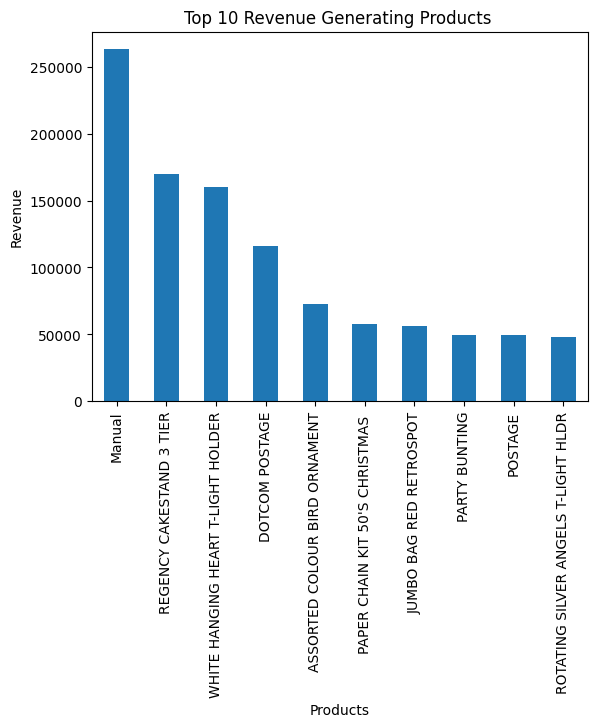

In [48]:
product_revenue.head(10).plot(kind='bar')
plt.title("Top 10 Revenue Generating Products ")
plt.xlabel('Products')
plt.ylabel('Revenue')
plt.show()

### Observations
#### Observation 47 :   A few products contribute very high revenue, while many products generate only very small revenue amounts.
#### Observation 48 :   Products like “Manual”, “REGENCY CAKESTAND 3 TIER”, and “WHITE HANGING HEART T-LIGHT HOLDER” are among the top revenue-generating products in the business.

### Business Insights
#### Business Insight 1 :  The business depends heavily on a small number of high-performing products for major revenue generation.
#### Business Insight 2 :  Top-performing products should be prioritized in inventory management, promotions, and marketing strategies to maximize business revenue.

5. Which customers spend the most money?

In [49]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue.head(10)

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196549.74
14911.0    152121.22
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: Revenue, dtype: float64

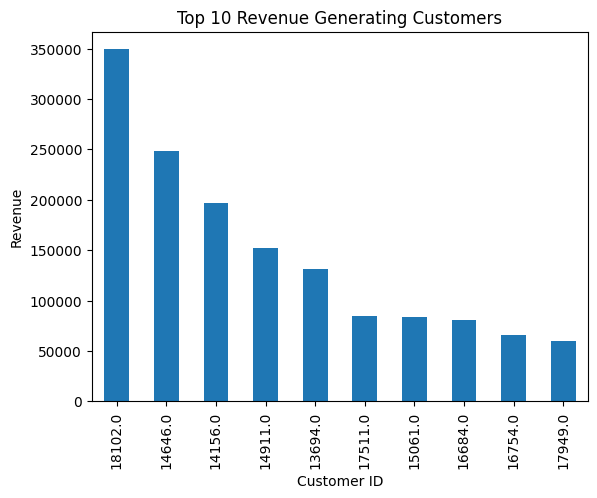

In [50]:
customer_revenue.head(10).plot(kind='bar')
plt.title("Top 10 Revenue Generating Customers")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.ticklabel_format(style="plain",axis='y')
plt.show()

### Observations 
#### Observation 49 :   Some customers have extremely high spending values, showing that the business has a few high-value customers driving major sales.

### Business Insights
#### Business Insight 1 :  The business depends significantly on a small group of high-spending customers for revenue generation.
#### Business Insight 2 :  The company can improve customer retention and loyalty programs for high-value customers to maintain long-term revenue growth.

6. Which days generate the highest revenue?

In [51]:
df['Weekday'] =df['InvoiceDate'].dt.day_name()

In [52]:
weekday_revenue = df.groupby('Weekday')['Revenue'].sum().sort_values(ascending=False)
weekday_revenue

Weekday
Thursday     2097097.802
Tuesday      2002003.301
Monday       1860809.825
Wednesday    1745382.103
Friday       1533319.022
Sunday       1023721.131
Saturday        9803.050
Name: Revenue, dtype: float64

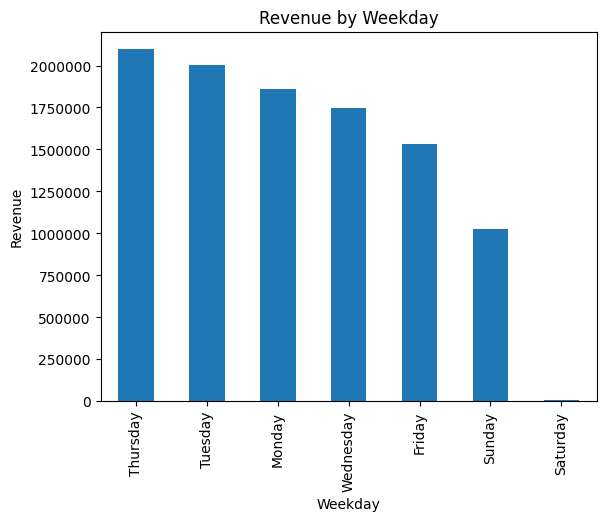

In [53]:
weekday_revenue.plot(kind='bar')

plt.title('Revenue by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Revenue')

plt.ticklabel_format(style='plain', axis='y')

plt.show()

### Observations 
#### Observation 50 : Thursday, Tuesday, and Monday generated the highest revenue, showing strong customer purchasing activity during weekdays.
#### Observation 51 : Saturday generated extremely low revenue compared to other days, indicating very limited business activity on Saturdays.

### Business Insights
#### Business Insight 1 :   Customer purchases are concentrated more on weekdays, especially during the middle of the week.
#### Business Insight 2 :   The business can focus promotional campaigns and operational planning more heavily on high-performing weekdays to maximize revenue.

7. What is the average revenue generated per order?

In [54]:
order_revenue = df.groupby('Invoice')['Revenue'].sum().sort_values(ascending=False)
order_revenue

Invoice
533027    49844.99
531516    45332.97
493819    44051.60
524181    33167.80
526934    26007.08
            ...   
529767        0.42
518991        0.42
507293        0.42
502731        0.42
528127        0.19
Name: Revenue, Length: 20952, dtype: float64

In [55]:
avg_order_value = order_revenue.mean()
avg_order_value

490.2699615311188

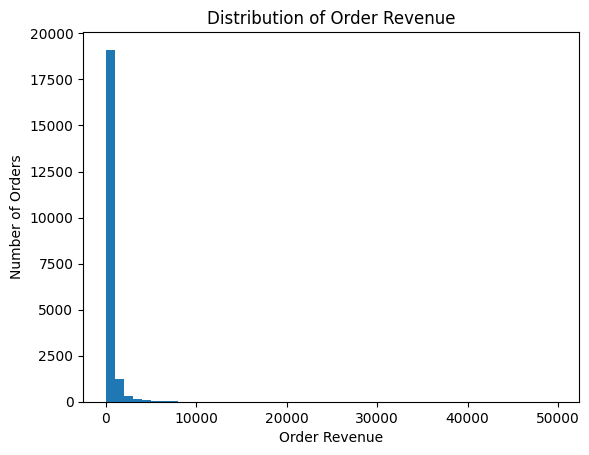

In [56]:
plt.hist(order_revenue,bins=50)
plt.title('Distribution of Order Revenue')
plt.xlabel('Order Revenue')
plt.ylabel('Number of Orders')
plt.show()

### Observations
#### Observation 52 :   The average order value is around 490, showing that customers generally purchase multiple products in a single order.
#### Observation 53 :   Some orders have very high values, which increases the overall average order revenue.

### Business Insights
#### Business Insight 1 :   Customers are not making very small purchases; instead, many orders contain multiple items, leading to healthy order values.
#### Business Insight 2 :   The business can further increase average order value using bundle offers, combo deals, and product recommendations.

8. At what time do customers purchase the most?

In [57]:
hourly_revenue = df.groupby('Hour')['Revenue'].sum().sort_index()
hourly_revenue

Hour
7       45173.360
8      248940.430
9      811807.660
10    1180711.352
11    1339629.933
12    1459647.691
13    1330157.834
14    1199013.910
15    1121576.882
16     884153.701
17     416238.591
18     136836.100
19      77876.440
20      20372.350
Name: Revenue, dtype: float64

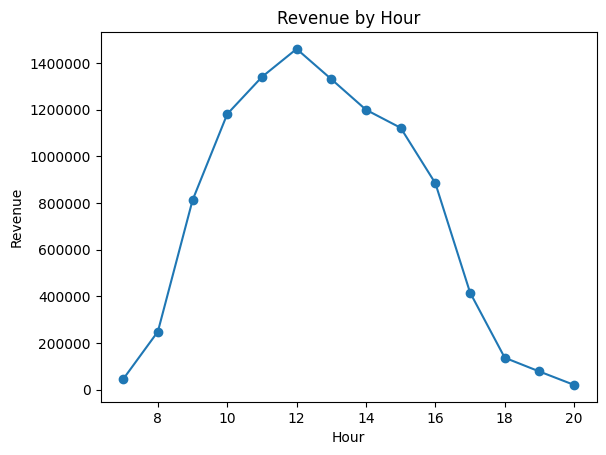

In [58]:
hourly_revenue.plot(kind='line',marker='o')
plt.title('Revenue by Hour')
plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain',axis='y')
plt.show()

### Observations
#### Observation 54 :   Revenue is highest during late morning and afternoon hours, especially around 11 AM to 3 PM.
#### Observation 55 :   Revenue drops significantly during early morning and evening hours, showing lower customer purchasing activity.

### Business Insights
#### Business Insight 1 :  Customers prefer shopping during daytime business hours, indicating peak operational activity in the afternoon period.
#### Business Insight 2 :  The company can schedule marketing campaigns, staff allocation, and delivery operations during peak shopping hours to improve efficiency and sales.

9. Which months or seasons have highest sales activity?

In [59]:
monthly_orders = df.groupby('YearMonth')['Invoice'].nunique()
monthly_orders

YearMonth
2009-12    1682
2010-01    1105
2010-02    1202
2010-03    1681
2010-04    1462
2010-05    1500
2010-06    1645
2010-07    1529
2010-08    1425
2010-09    1839
2010-10    2301
2010-11    2747
2010-12     834
Freq: M, Name: Invoice, dtype: int64

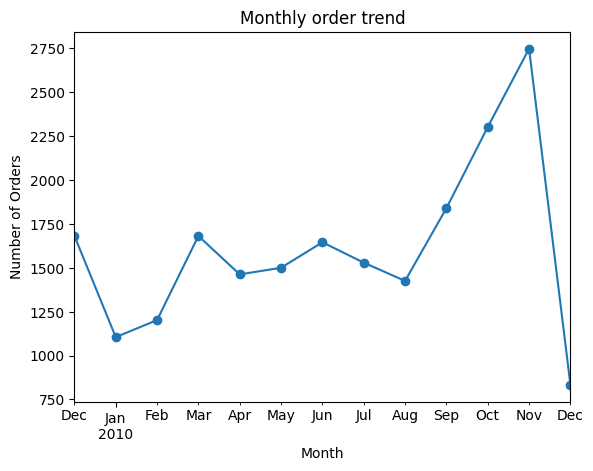

In [60]:
monthly_orders.plot(kind='line',marker='o')
plt.title('Monthly order trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.show()

### Observations
#### Observation 56 :   The number of customer orders increased significantly from September to November, with November showing the highest sales activity.
#### Observation 57 :   December 2010 shows a sudden drop in orders, likely because the dataset contains only partial month data.

### Business Insights
#### Business Insight 1 :   The business experiences strong seasonal demand during the end of the year, especially during festive and holiday shopping periods.
#### Business Insight 2 :   The company should prepare additional inventory, marketing campaigns, and operational support during high-demand months like October and November to maximize sales opportunities.

10. Are few customers contributing most of the revenue?

In [61]:
#### First checking customer revenue
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196549.74
14911.0    152121.22
13694.0    131443.19
             ...    
18115.0         9.70
15040.0         7.49
15913.0         6.30
13788.0         3.75
14095.0         2.95
Name: Revenue, Length: 4312, dtype: float64

In [62]:
#percentage Contribution
customer_revenue_percentage = (customer_revenue / customer_revenue.sum())*100
customer_revenue_percentage

Customer ID
18102.0    3.968573
14646.0    2.823254
14156.0    2.233968
14911.0    1.728997
13694.0    1.493972
             ...   
18115.0    0.000110
15040.0    0.000085
15913.0    0.000072
13788.0    0.000043
14095.0    0.000034
Name: Revenue, Length: 4312, dtype: float64

In [63]:
#cumulative percentage
cumulative_perct = customer_revenue_percentage.cumsum()
cumulative_perct.head(10)

Customer ID
18102.0     3.968573
14646.0     6.791827
14156.0     9.025796
14911.0    10.754793
13694.0    12.248765
17511.0    13.209653
15061.0    14.156257
16684.0    15.071090
16754.0    15.815559
17949.0    16.498850
Name: Revenue, dtype: float64

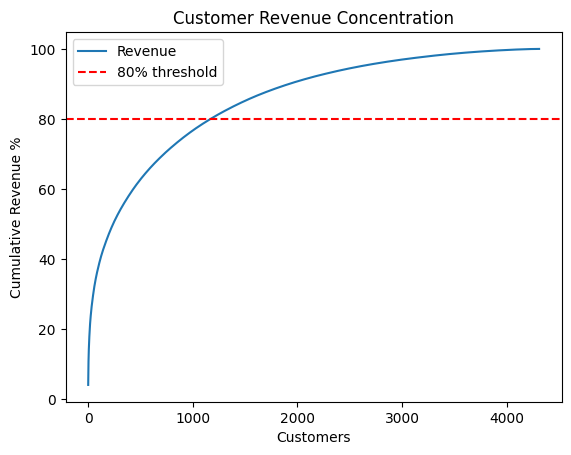

In [64]:
cumulative_perct.reset_index(drop=True).plot(kind='line')
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.title('Customer Revenue Concentration')
plt.xlabel('Customers')
plt.ylabel('Cumulative Revenue %')
plt.legend()
plt.show()

### Observations
#### Observation 58 :   Top customers contribute a significant portion of revenue, but revenue is still distributed across many customers.
#### Observation 59 :   Revenue contribution increases gradually as more customers are included, showing balanced customer participation.

### BUSINESS INSIGHT 
#### Business Insight 1 :  The company has a relatively balanced customer base, which reduces the risk of losing revenue from a single customer.
#### Business Insight 2 :  High-value customers still play an important role in business growth, so the company should focus on customer retention and loyalty programs for top customers.

11. What percentage of total revenue comes from top products?

In [65]:
#total revenue generated by each product.
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
product_revenue

Description
Manual                                262963.430
REGENCY CAKESTAND 3 TIER              169912.760
WHITE HANGING HEART T-LIGHT HOLDER    160345.630
DOTCOM POSTAGE                        116408.710
ASSORTED COLOUR BIRD ORNAMENT          72890.190
                                         ...    
SILICON CUBE 25W, BLUE                     0.420
PINK HEART CHRISTMAS DECORATION            0.380
HAPPY BIRTHDAY GINGER CAT CARD             0.380
CHAMPAGNE TRAY BLANK CARD                  0.380
PADS TO MATCH ALL CUSHIONS                 0.014
Name: Revenue, Length: 4534, dtype: float64

In [66]:
#Percentage Contribution
product_percentage = (product_revenue / product_revenue.sum())*100
product_percentage

Description
Manual                                2.559968e+00
REGENCY CAKESTAND 3 TIER              1.654113e+00
WHITE HANGING HEART T-LIGHT HOLDER    1.560976e+00
DOTCOM POSTAGE                        1.133247e+00
ASSORTED COLOUR BIRD ORNAMENT         7.095913e-01
                                          ...     
SILICON CUBE 25W, BLUE                4.088731e-06
PINK HEART CHRISTMAS DECORATION       3.699328e-06
HAPPY BIRTHDAY GINGER CAT CARD        3.699328e-06
CHAMPAGNE TRAY BLANK CARD             3.699328e-06
PADS TO MATCH ALL CUSHIONS            1.362910e-07
Name: Revenue, Length: 4534, dtype: float64

In [67]:
#Cumulative Percentage
product_cumulative = product_percentage.cumsum()
product_cumulative.head(10)

Description
Manual                                  2.559968
REGENCY CAKESTAND 3 TIER                4.214081
WHITE HANGING HEART T-LIGHT HOLDER      5.775058
DOTCOM POSTAGE                          6.908305
ASSORTED COLOUR BIRD ORNAMENT           7.617897
PAPER CHAIN KIT 50'S CHRISTMAS          8.183770
JUMBO BAG RED RETROSPOT                 8.733612
PARTY BUNTING                           9.217095
POSTAGE                                 9.698763
ROTATING SILVER ANGELS T-LIGHT HLDR    10.165603
Name: Revenue, dtype: float64

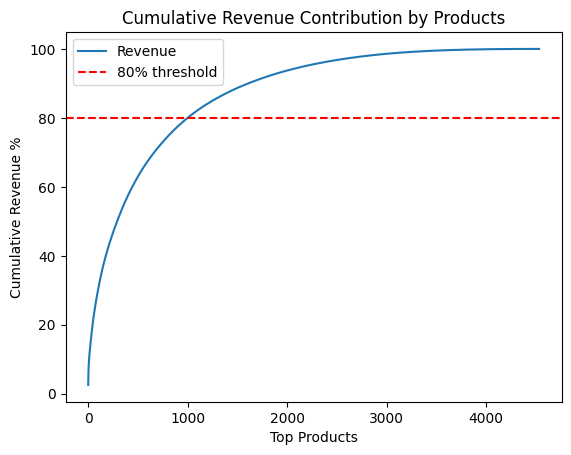

In [68]:
product_cumulative.reset_index(drop=True).plot(kind='line')
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.title('Cumulative Revenue Contribution by Products')
plt.xlabel('Top Products')
plt.ylabel('Cumulative Revenue %')
plt.legend()
plt.show()

### Observations
#### Observation 59 :   Revenue contribution increases gradually across products, showing that revenue is spread across many products rather than depending on only a few items.
#### Observation 60 :   Some top products contribute higher revenue, but a large number of products together contribute significantly to total business revenue.

### BUSINESS INSIGHT 
#### Business Insight 1 :   Business revenue comes from many products instead of depending on only a few products.
#### Business Insight 2 :   High-performing products should be prioritized for promotions, while low-performing products can be reviewed for optimization strategies.

12. What percentage of total revenue comes from top Country?

In [69]:
#Total Revenue by Country
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_revenue

Country
United Kingdom          8812685.403
EIRE                     380909.570
Netherlands              268784.350
Germany                  202025.391
France                   147103.140
Sweden                    53501.990
Denmark                   50906.850
Spain                     47568.650
Switzerland               43921.390
Australia                 31446.800
Channel Islands           24546.320
Belgium                   24537.580
Portugal                  24265.000
Norway                    23944.180
Italy                     15052.730
Greece                    14335.670
Austria                   13414.330
Cyprus                    11347.100
Japan                      9722.020
United Arab Emirates       9195.350
Hong Kong                  8202.520
Finland                    7379.460
Unspecified                6186.220
Malta                      5373.500
Lithuania                  4892.680
USA                        4786.470
Singapore                  4037.770
RSA                 

In [70]:
#Percentage Contribution
country_percentage = (country_revenue / country_revenue.sum())*100
country_percentage

Country
United Kingdom          85.792139
EIRE                     3.708183
Netherlands              2.616635
Germany                  1.966732
France                   1.432060
Sweden                   0.520846
Denmark                  0.495582
Spain                    0.463084
Switzerland              0.427578
Australia                0.306137
Channel Islands          0.238960
Belgium                  0.238875
Portugal                 0.236222
Norway                   0.233098
Italy                    0.146539
Greece                   0.139559
Austria                  0.130589
Cyprus                   0.110465
Japan                    0.094645
United Arab Emirates     0.089517
Hong Kong                0.079852
Finland                  0.071840
Unspecified              0.060223
Malta                    0.052311
Lithuania                0.047631
USA                      0.046597
Singapore                0.039308
RSA                      0.037013
Poland                   0.034733
Israel

In [71]:
#Cumulative Contribution
country_cumulative = country_percentage.cumsum()
country_cumulative

Country
United Kingdom           85.792139
EIRE                     89.500322
Netherlands              92.116957
Germany                  94.083689
France                   95.515749
Sweden                   96.036595
Denmark                  96.532177
Spain                    96.995261
Switzerland              97.422839
Australia                97.728976
Channel Islands          97.967936
Belgium                  98.206811
Portugal                 98.443033
Norway                   98.676131
Italy                    98.822671
Greece                   98.962229
Austria                  99.092819
Cyprus                   99.203284
Japan                    99.297928
United Arab Emirates     99.387446
Hong Kong                99.467298
Finland                  99.539137
Unspecified              99.599361
Malta                    99.651672
Lithuania                99.699303
USA                      99.745899
Singapore                99.785207
RSA                      99.822220
Poland      

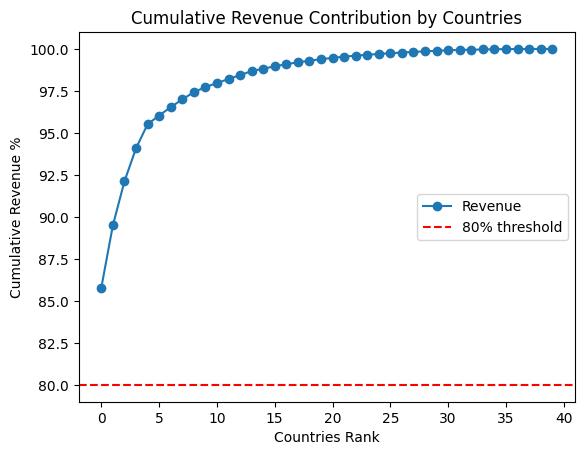

In [72]:
country_cumulative.reset_index(drop=True).plot(kind='line',marker='o')
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.title('Cumulative Revenue Contribution by Countries')
plt.xlabel('Countries Rank')
plt.ylabel('Cumulative Revenue %')
plt.legend()
plt.show()

In [73]:
df.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName,Day,DayName,Hour,YearMonth,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday,7,2009-12,Tuesday


12.Does selling more quantity increase revenue?

In [74]:
#Group Quantity & Revenue by Invoice
invoice_analysis = df.groupby('Invoice')[['Quantity','Revenue']].sum()

invoice_analysis.head()

,Quantity,Revenue
Invoice,,
489434,166,505.30
489435,60,145.80
489436,193,630.33
489437,145,310.75
489438,826,2286.24


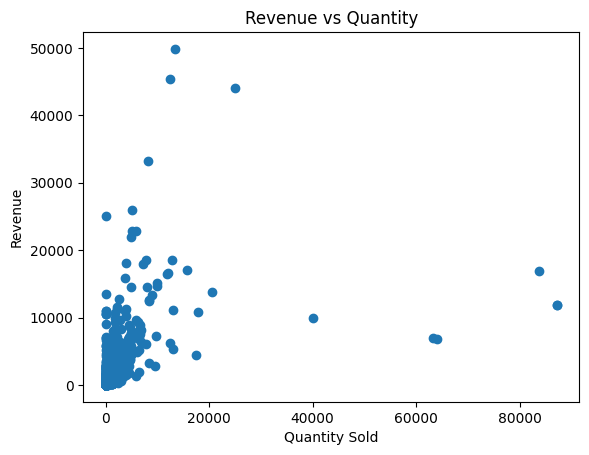

In [75]:
plt.scatter(invoice_analysis['Quantity'],
            invoice_analysis['Revenue'])

plt.title('Revenue vs Quantity')
plt.xlabel('Quantity Sold')
plt.ylabel('Revenue')

plt.show()

### Observation
#### Observation 1 :    Most points are close to the bottom left, meaning many products have low quantity sold and low revenue.
#### Observation 2 :    A few points are far away from the cluster, showing some products sold in large quantities or earned very high revenue — these are outliers.

### Business Insight
#### Business Insight 1 :    Selling more quantity doesn’t always mean more revenue — some high‑quantity items may have low prices.
#### Business Insight 2 :    The company should study the high‑revenue products to understand what makes them successful and try to increase sales of similar items.

13.How does business revenue perform across different quarters?

In [76]:
#Create Quarter Column
df['Quarter'] = df['InvoiceDate'].dt.quarter 

In [77]:
#Quarterly Revenue
quartely_revenue = df.groupby('Quarter')['Revenue'].sum()
quartely_revenue

Quarter
1    2033948.669
2    2086118.062
3    2265759.171
4    3886310.332
Name: Revenue, dtype: float64

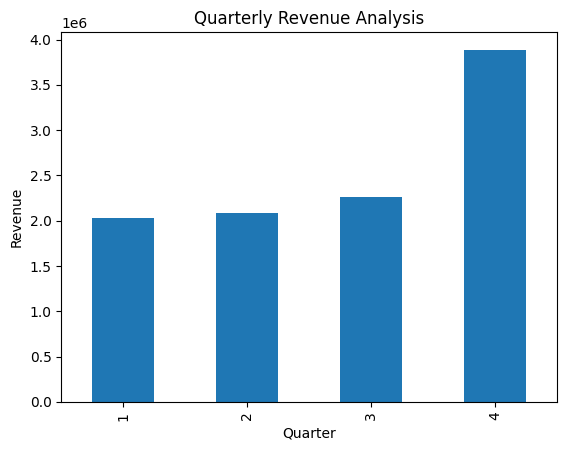

In [78]:
#Visualization
quartely_revenue.plot(kind='bar')
plt.title('Quarterly Revenue Analysis')
plt.xlabel('Quarter')
plt.ylabel('Revenue')

plt.show()

### OBSERVATION
#### Observation 1 : Quarter 4 generated significantly higher revenue compared to all other quarters.
#### Observation 2:  The company should prepare more inventory and marketing campaigns during Quarter 4 to maximize revenue.

### BUSINESS INSIGHT
#### Bussiness Insight 1:   The business experiences strongest sales performance during the end of the year.
#### Bussiness Insight 2 : The company should prepare more inventory and marketing campaigns during Quarter 4 to maximize revenue.

14. Are most orders low-value, medium-value, or high-value?

In [79]:
#Create Total Revenue per Order
invoice_revenue = df.groupby('Invoice')['Revenue'].sum()
invoice_revenue

Invoice
489434      505.30
489435      145.80
489436      630.33
489437      310.75
489438     2286.24
            ...   
538168      310.45
538169       93.45
538170      317.59
538171      300.64
C496350     373.57
Name: Revenue, Length: 20952, dtype: float64

In [80]:
#Create Revenue Segments
segments = pd.cut(invoice_revenue, bins=[0,100,500,50000],labels=['Low','Medium','High'])

segments.head()

Invoice
489434      High
489435    Medium
489436      High
489437    Medium
489438      High
Name: Revenue, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [81]:
#Counting orders in each segment
segment_count = segments.value_counts()

segment_count

Revenue
Medium    12631
High       5088
Low        3233
Name: count, dtype: int64

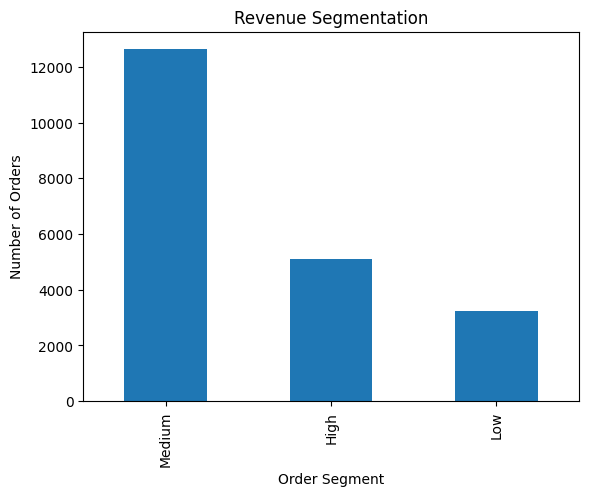

In [82]:
segment_count.plot(kind='bar')

plt.title('Revenue Segmentation')
plt.xlabel('Order Segment')
plt.ylabel('Number of Orders')

plt.show()

### OBSERVATION
#### Observation 1 : Most customer orders fall under the medium revenue category.
#### Observation 2:  Low-value orders are fewer compared to medium and high-value orders.

### BUSINESS INSIGHT
#### Bussiness Insight 1:   The business mainly earns through medium-sized customer purchases.
#### Bussiness Insight 2 : The company has opportunities to convert medium-value customers into high-value customers through upselling and promotions.

### Product Analysis(EDA)

1.  Which products sold the highest quantity?

In [83]:
top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_products_qty.head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    58691
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54947
BROCADE RING PURSE                    48374
PACK OF 72 RETRO SPOT CAKE CASES      46728
ASSORTED COLOUR BIRD ORNAMENT         45228
60 TEATIME FAIRY CAKE CASES           36348
PACK OF 60 PINK PAISLEY CAKE CASES    31805
JUMBO BAG RED RETROSPOT               30746
SMALL POPCORN HOLDER                  29773
STRAWBERRY CERAMIC TRINKET BOX        27059
Name: Quantity, dtype: int64

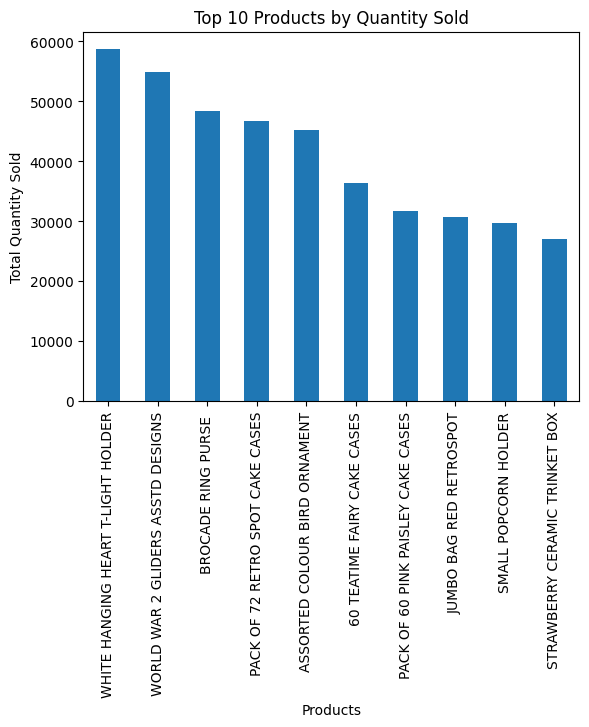

In [84]:
#Visualization
top_products_qty.head(10).plot(kind='bar')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Products')
plt.ylabel('Total Quantity Sold')

plt.show()

### OBSERVATION 
##### 1. WHITE HANGING HEART T-LIGHT HOLDER is the most sold product by quantity.
##### 2. Decorative and gift-related products appear frequently among top-selling items.

### BUSINESS INSIGHT
#### 1. Customers are highly interested in home décor and gift-style products.
#### 2. Business can maintain higher stock for these fast-moving products to avoid stock shortages.

2.  Which products generate the highest revenue?

In [85]:
top_products_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5)
top_products_revenue

Description
Manual                                262963.43
REGENCY CAKESTAND 3 TIER              169912.76
WHITE HANGING HEART T-LIGHT HOLDER    160345.63
DOTCOM POSTAGE                        116408.71
ASSORTED COLOUR BIRD ORNAMENT          72890.19
Name: Revenue, dtype: float64

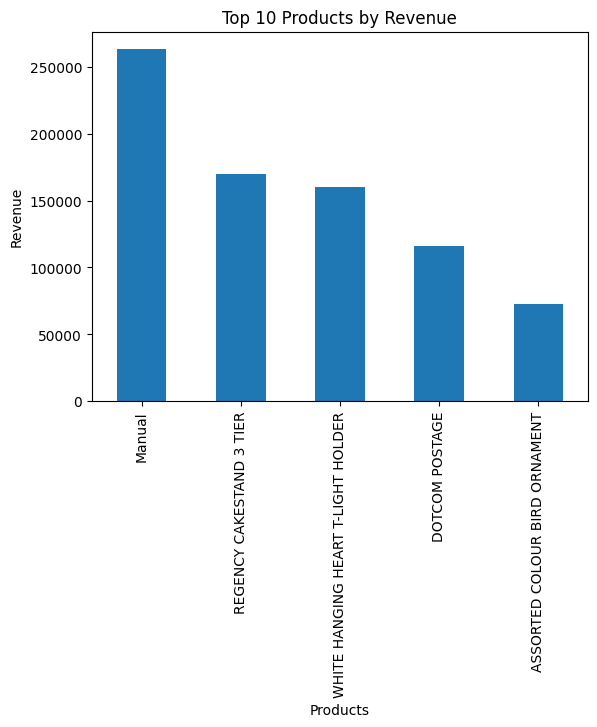

In [86]:
#Visualization
top_products_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Products')
plt.ylabel('Revenue')

plt.show()

### OBSERVATION 
##### 1. Manual generated the highest revenue among all products.
##### 2.Decorative and gifting products contribute significantly to overall business revenue.

### BUSINESS INSIGHT
#### 1. High-revenue products should receive priority in marketing and inventory planning
#### 2. The business earns strong revenue from premium and decorative product categories.

3.  Which products sold the least?

In [87]:
least_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=True)
least_products.head(10)

Description
FRENCH STYLE WIRE DOOR CABINET         1
IVORY PENDANT SHELL NECKLACE           1
F.FAIRY S/3 SML CANDLE, LAVENDER       1
WHITE CHRISTMAS TREE 60CM              1
F FAIRY POTPOURRI CUSHIONS SUMMER      1
EURO FOOTBALL STARS TOP TRUMPS GAME    1
ETCHED GLASS HEART TREE DECORATION     1
HOLLYHOCK SQUARE HANDY TIN             1
HEXAGONAL CRYSTAL PERFUME BOTTLE       1
ENGLISH ROSE TEA FOR ONE GIFT BOX      1
Name: Quantity, dtype: int64

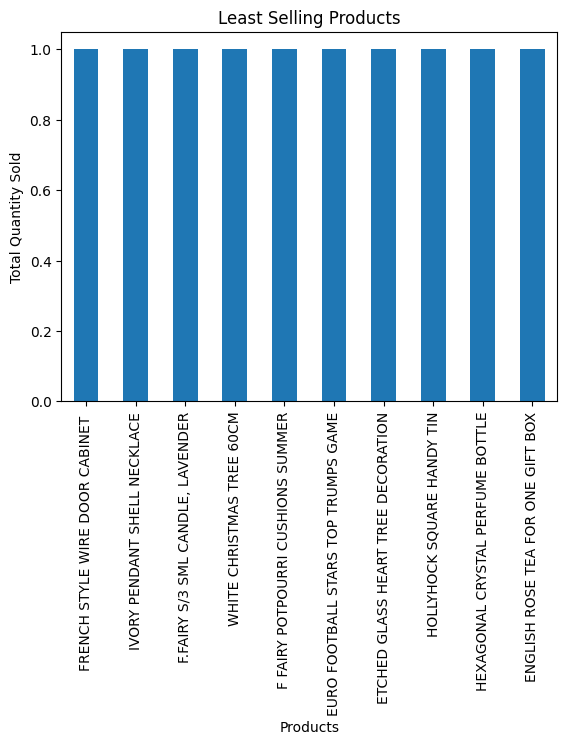

In [88]:
#Visualization
least_products.head(10).plot(kind='bar')
plt.title('Least Selling Products')
plt.xlabel('Products')
plt.ylabel('Total Quantity Sold')

plt.show()

### OBSERVATION 
##### 1. Several products were sold only once, showing extremely low sales demand.
##### 2. These low-performing products contribute very little to total product sales.

### BUSINESS INSIGHT
#### 1. The business can review low-selling products for possible discontinuation or promotional improvement.
#### 2. Some low-demand products may require better marketing or seasonal targeting strategies.

4.  Which products are purchased most frequently?

In [89]:
frequent_product = df['Description'].value_counts()
frequent_product.head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    3409
REGENCY CAKESTAND 3 TIER              2034
STRAWBERRY CERAMIC TRINKET BOX        1678
PACK OF 72 RETRO SPOT CAKE CASES      1435
ASSORTED COLOUR BIRD ORNAMENT         1435
60 TEATIME FAIRY CAKE CASES           1372
HOME BUILDING BLOCK WORD              1349
JUMBO BAG RED RETROSPOT               1270
LUNCH BAG RED SPOTTY                  1231
JUMBO STORAGE BAG SUKI                1193
Name: count, dtype: int64

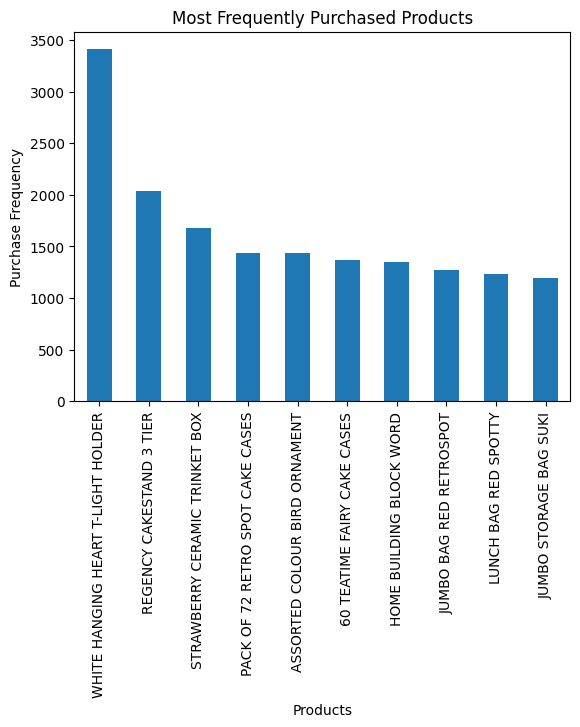

In [90]:
#Visualization
frequent_product.head(10).plot(kind='bar')

plt.title('Most Frequently Purchased Products')
plt.xlabel('Products')
plt.ylabel('Purchase Frequency')

plt.show()

### OBSERVATION 
##### 1. The product “WHITE HANGING HEART T‑LIGHT HOLDER” has the highest purchase frequency — it’s the most popular item.
##### 2.Other products like “REGENCY CAKESTAND 3 TIER” and “STRAWBERRY CERAMIC TRINKET BOX” are also bought often, while “JUMBO STORAGE BAG SUKI” is the least purchased among the top 10.

### BUSINESS INSIGHT
#### 1. The company should keep enough stock of the top‑selling items to avoid running out, since they drive most sales.
#### 2. Products with low purchase frequency may need better marketing, discounts, or design changes to attract more buyers.

5.  What percentage of total revenue comes from top products?

In [91]:
products_percentage = (top_products_revenue / top_products_revenue.sum())*100
product_percentage.head(10)

Description
Manual                                 2.559968
REGENCY CAKESTAND 3 TIER               1.654113
WHITE HANGING HEART T-LIGHT HOLDER     1.560976
DOTCOM POSTAGE                         1.133247
ASSORTED COLOUR BIRD ORNAMENT          0.709591
PAPER CHAIN KIT 50'S CHRISTMAS         0.565874
JUMBO BAG RED RETROSPOT                0.549841
PARTY BUNTING                          0.483484
POSTAGE                                0.481667
ROTATING SILVER ANGELS T-LIGHT HLDR    0.466840
Name: Revenue, dtype: float64

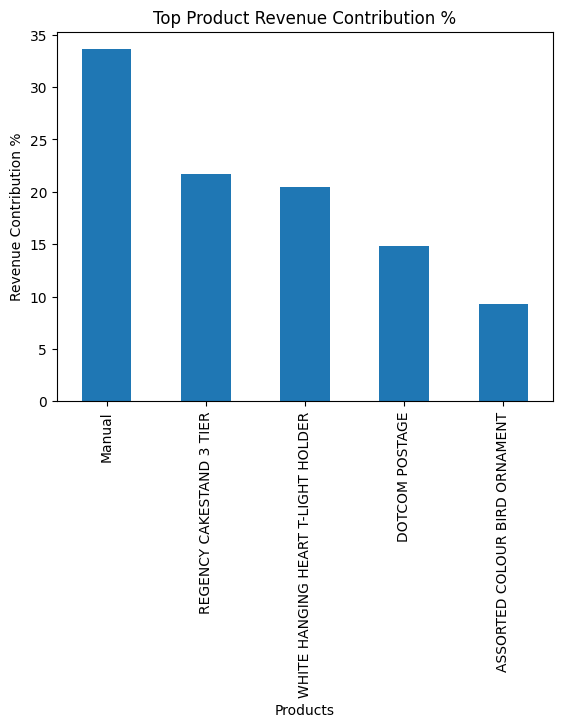

In [92]:
#Visualization
products_percentage.head(10).plot(kind='bar')

plt.title('Top Product Revenue Contribution %')
plt.xlabel('Products')
plt.ylabel('Revenue Contribution %')

plt.show()

### OBSERVATION 
##### 1. The product “Manual” gives the highest share of revenue, a little above 2.5 %.
##### 2. Other products like “REGENCY CAKESTAND 3 TIER” and “WHITE HANGING HEART T‑LIGHT HOLDER” also contribute well, while the last few items add very little to total revenue.

### BUSINESS INSIGHT
#### 1. A few products bring in most of the money — these are your key revenue drivers.
#### 2. The company should focus on promoting and keeping stock of these top products, and look for ways to increase sales of the lower‑performing ones.

6.  Which products sell high quantity but generate low revenue, and which products sell low quantity but generate high revenue?

In [93]:
#creating product summary
product_analysis = df.groupby('Description').agg({
    'Quantity' : 'sum',
    'Revenue'  : 'sum'
    })
product_analysis.head()

,Quantity,Revenue
Description,,
DOORMAT UNION JACK GUNS AND ROSES,177,1193.31
3 STRIPEY MICE FELTCRAFT,691,1342.03
4 PURPLE FLOCK DINNER CANDLES,207,298.11
ANIMAL STICKERS,385,80.85
BLACK PIRATE TREASURE CHEST,55,108.48


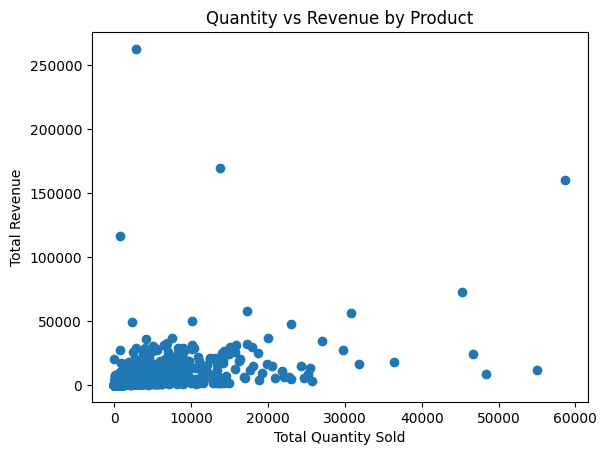

In [94]:
#Visualazation
plt.scatter(product_analysis['Quantity'],product_analysis['Revenue'])
plt.title('Quantity vs Revenue by Product')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Total Revenue')
plt.show()


### OBSERVATION 
##### 1. Most products are grouped near the bottom left, meaning they have low quantity sold and low revenue.
##### 2. A few products stand out far above the cluster — they have very high revenue or high quantity sold, showing they perform much better than others.

### BUSINESS INSIGHT
#### 1. Only a few products are major revenue drivers — focus marketing and stock on them.
#### 2. Many products are low sellers — consider promotions, redesigns, or discontinuing them.
#### 3. High‑revenue but low‑quantity items could be premium products — maintain their exclusivity and quality.
#### 4. High‑quantity but low‑revenue items might need price adjustments or cost control to improve profit.

7. Which products are seasonal and perform strongly during certain months?

In [95]:
#top Products
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head().index
top_products

Index(['Manual', 'REGENCY CAKESTAND 3 TIER',
       'WHITE HANGING HEART T-LIGHT HOLDER', 'DOTCOM POSTAGE',
       'ASSORTED COLOUR BIRD ORNAMENT'],
      dtype='object', name='Description')

In [96]:
#Filterdataset which belongs topproducts only
seasonal_products = df[df['Description'].isin(top_products)]
seasonal_products

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName,Day,DayName,Hour,YearMonth,Weekday,Quarter
15,489436,84879,ASSORTED COLOUR BIRD ORNAMENT,16,2009-12-01 09:06:00,1.69,13078.0,United Kingdom,27.04,2009,12,December,1,Tuesday,9,2009-12,Tuesday,4
102,489442,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom,17.70,2009,12,December,1,Tuesday,9,2009-12,Tuesday,4
147,489446,85123A,WHITE HANGING HEART T-LIGHT HOLDER,32,2009-12-01 10:06:00,2.55,13758.0,United Kingdom,81.60,2009,12,December,1,Tuesday,10,2009-12,Tuesday,4
271,489465,85123A,WHITE HANGING HEART T-LIGHT HOLDER,64,2009-12-01 10:52:00,2.55,13767.0,United Kingdom,163.20,2009,12,December,1,Tuesday,10,2009-12,Tuesday,4
282,489465,84879,ASSORTED COLOUR BIRD ORNAMENT,160,2009-12-01 10:52:00,1.45,13767.0,United Kingdom,232.00,2009,12,December,1,Tuesday,10,2009-12,Tuesday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525147,538154,DOT,DOTCOM POSTAGE,1,2010-12-09 16:35:00,85.79,NaN,United Kingdom,85.79,2010,12,December,9,Thursday,16,2010-12,Thursday,4
525217,538156,22423,REGENCY CAKESTAND 3 TIER,6,2010-12-09 16:53:00,12.75,15555.0,United Kingdom,76.50,2010,12,December,9,Thursday,16,2010-12,Thursday,4
525223,538157,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4,2010-12-09 16:57:00,2.95,17576.0,United Kingdom,11.80,2010,12,December,9,Thursday,16,2010-12,Thursday,4
525301,538166,85123A,WHITE HANGING HEART T-LIGHT HOLDER,3,2010-12-09 18:09:00,2.95,17965.0,United Kingdom,8.85,2010,12,December,9,Thursday,18,2010-12,Thursday,4


In [97]:
#monthly product revenue
monthly_product_sales = seasonal_products.groupby(['YearMonth','Description'])['Revenue'].sum().unstack()
monthly_product_sales

Description,ASSORTED COLOUR BIRD ORNAMENT,DOTCOM POSTAGE,Manual,REGENCY CAKESTAND 3 TIER,WHITE HANGING HEART T-LIGHT HOLDER
YearMonth,,,,,
2009-12,7623.93,18574.58,2237.39,NaN,17255.35
2010-01,2634.61,11340.51,15621.17,NaN,14700.79
2010-02,2686.03,6443.50,4573.10,NaN,8030.57
2010-03,5229.57,9993.76,54884.62,9865.11,14222.90
2010-04,4734.41,4786.15,23370.61,14383.09,10048.51
2010-05,3557.68,5412.17,5085.46,6771.88,11952.74
2010-06,3052.14,4930.22,43179.57,16577.53,11828.66
2010-07,5032.05,6655.29,5420.06,18865.88,10782.49
2010-08,5028.59,6671.23,10731.91,13258.53,12834.91


In [98]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

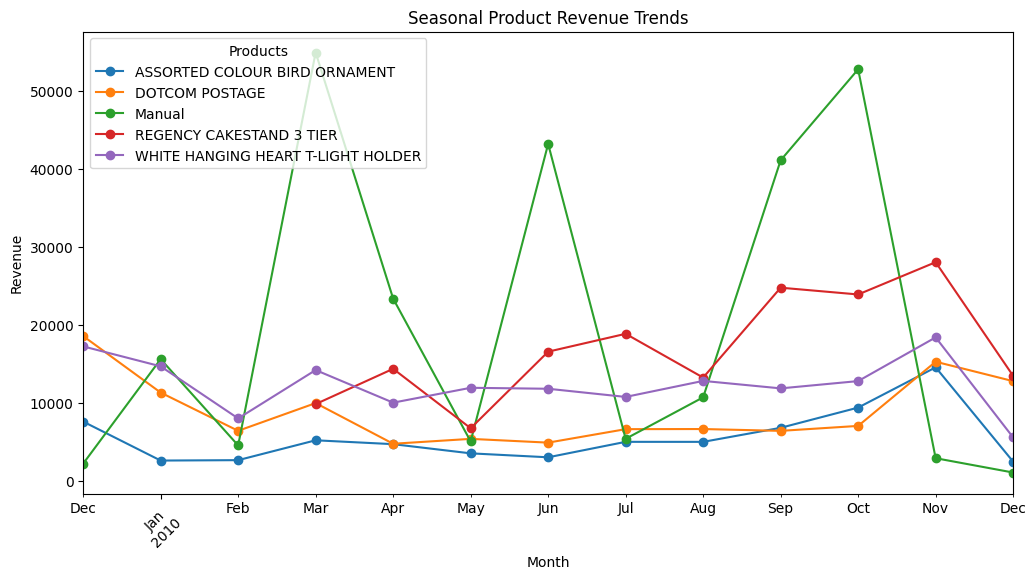

In [99]:
#Visualization
monthly_product_sales.plot(kind='line',figsize=(12,6), marker='o')

plt.title('Seasonal Product Revenue Trends')

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend(title='Products')
plt.xticks(rotation=45)
plt.show()

### OBSERVATION 
##### 1. Some products show stable sales throughout the year, while others experience sudden revenue spikes in specific months.
##### 2. Products like WHITE HANGING HEART T-LIGHT HOLDER maintain consistent performance, whereas products like Manual show seasonal fluctuations.

### BUSINESS INSIGHT
#### 1. Stable products should always be kept in stock because they generate regular revenue.
#### 2. Seasonal products should be stocked more during high-demand months to maximize sales opportunities.

8. Which products are most popular in different countries?

In [100]:
#find top countries
top_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head()
top_country

Country
United Kingdom    8812685.403
EIRE               380909.570
Netherlands        268784.350
Germany            202025.391
France             147103.140
Name: Revenue, dtype: float64

In [101]:
#Filter Only Top Countries
country_data = df[df['Country'].isin(top_country.index)]
country_data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName,Day,DayName,Hour,YearMonth,Weekday,Quarter
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009,12,December,1,Tuesday,7,2009-12,Tuesday,4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009,12,December,1,Tuesday,7,2009-12,Tuesday,4
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009,12,December,1,Tuesday,7,2009-12,Tuesday,4
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009,12,December,1,Tuesday,7,2009-12,Tuesday,4
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009,12,December,1,Tuesday,7,2009-12,Tuesday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90,2010,12,December,9,Thursday,20,2010-12,Thursday,4
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,2010,12,December,9,Thursday,20,2010-12,Thursday,4
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,2010,12,December,9,Thursday,20,2010-12,Thursday,4
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50,2010,12,December,9,Thursday,20,2010-12,Thursday,4


In [102]:
#Find Top Products per Country
top_country_products = country_data.groupby([
    'Country','Description'
])['Quantity'].sum().reset_index().sort_values(by='Quantity',ascending=False).head(10)
top_country_products

,Country,Description,Quantity
10508,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,53166
10612,United Kingdom,WORLD WAR 2 GLIDERS ASSTD DESIGNS,51683
6884,United Kingdom,BROCADE RING PURSE,48186
6450,United Kingdom,ASSORTED COLOUR BIRD ORNAMENT,42158
8870,United Kingdom,PACK OF 72 RETRO SPOT CAKE CASES,36727
8296,United Kingdom,JUMBO BAG RED RETROSPOT,28178
6322,United Kingdom,60 TEATIME FAIRY CAKE CASES,27831
10095,United Kingdom,SMALL POPCORN HOLDER,27347
8868,United Kingdom,PACK OF 60 PINK PAISLEY CAKE CASES,25971
10178,United Kingdom,STRAWBERRY CERAMIC TRINKET BOX,25177


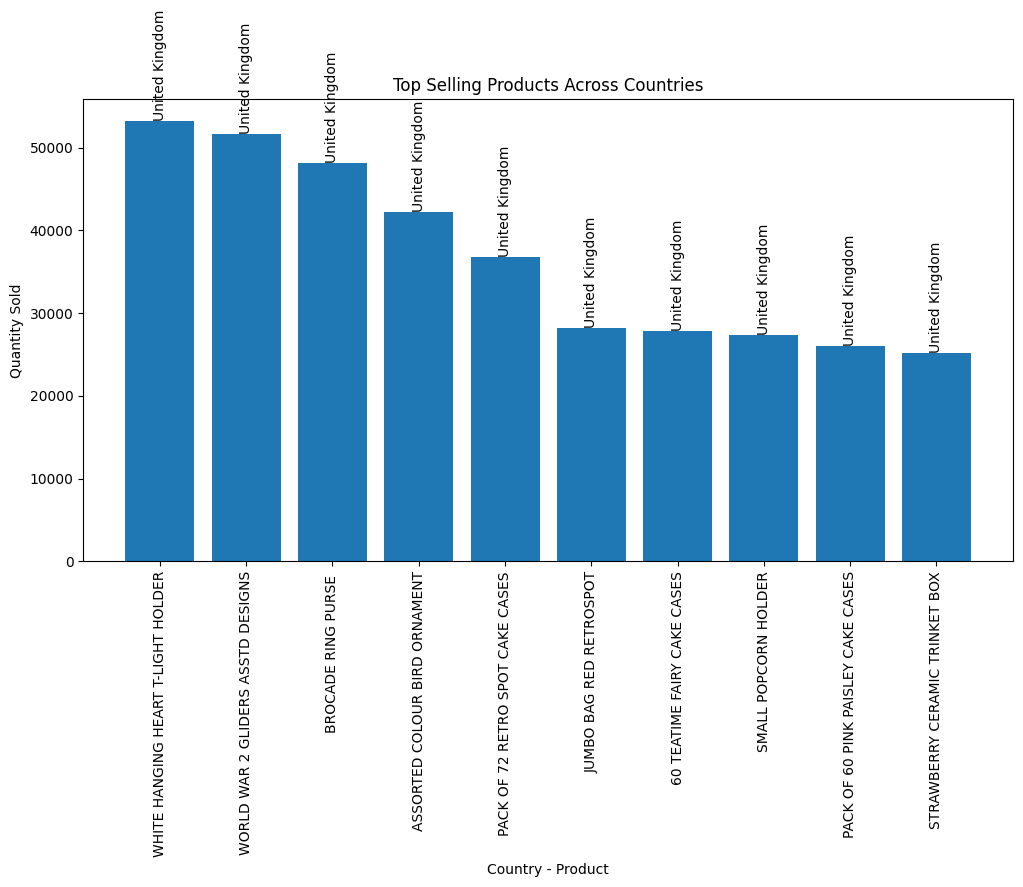

In [103]:
#Visualization
plt.figure(figsize=(12,6))
bars = plt.bar(
    #top_country_products['Country'] + '-' +
    top_country_products['Description'],
    top_country_products['Quantity']
)
plt.bar_label(
    bars,
    labels=top_country_products['Country'],
    rotation=90
)
plt.xticks(rotation=90)

plt.title('Top Selling Products Across Countries')

plt.xlabel('Country - Product')
plt.ylabel('Quantity Sold')

plt.show()

### OBSERVATION 
##### 1. All top-selling products in this chart belong mainly to the United Kingdom market.
##### 2. WHITE HANGING HEART T-LIGHT HOLDER has the highest quantity sold among all products.


### BUSINESS INSIGHT
#### 1. Businesses can focus marketing campaigns on top-performing products to maximize sales.
#### 2. Products with consistently high sales can be prioritized for inventory and promotional strategies.

9. Which products contribute the most revenue to the business?

In [104]:
df.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName,Day,DayName,Hour,YearMonth,Weekday,Quarter
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday,7,2009-12,Tuesday,4


In [105]:
#Create Price Segments
df['Price_Category'] = pd.cut(
    df['Price'],
    bins=[0,5,20,1000],
    labels=['Low Price','Medium Price','High Price']
)

In [106]:
#Analyze Quantity Sold
price_analysis = df.groupby('Price_Category')['Quantity'].sum()
price_analysis

C:\Users\aishw\AppData\Local\Temp\ipykernel_1176\4232786868.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_analysis = df.groupby('Price_Category')['Quantity'].sum()


Price_Category
Low Price       5513164
Medium Price     291826
High Price         7900
Name: Quantity, dtype: int64

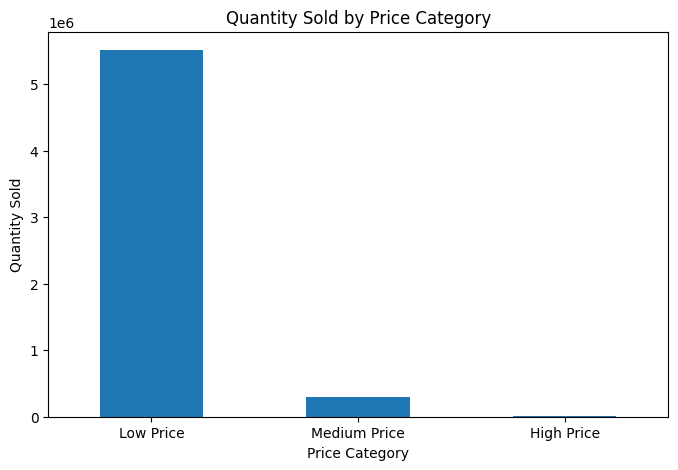

In [107]:
#Visualization
plt.figure(figsize=(8,5))

price_analysis.plot(kind='bar')

plt.title('Quantity Sold by Price Category')

plt.xlabel('Price Category')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=0)

plt.show()

### OBSERVATION 
##### 1. Most of the quantity sold comes from low‑price products, far higher than medium or high‑price ones.
##### 2. Medium‑ and high‑price categories have very small sales volumes compared to low‑price items.


### BUSINESS INSIGHT
#### 1. Customers prefer affordable products, showing strong demand in the low‑price range.
#### 2. The company could increase profit by introducing slightly higher‑priced versions of popular low‑price items or improving marketing for medium‑price products.

### Customer Analysis(EDA)

1. Which customers generate the highest revenue for the business?

In [108]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue.head(10)

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196549.74
14911.0    152121.22
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: Revenue, dtype: float64

In [109]:
customer_revenue.index = customer_revenue.index.astype(int)

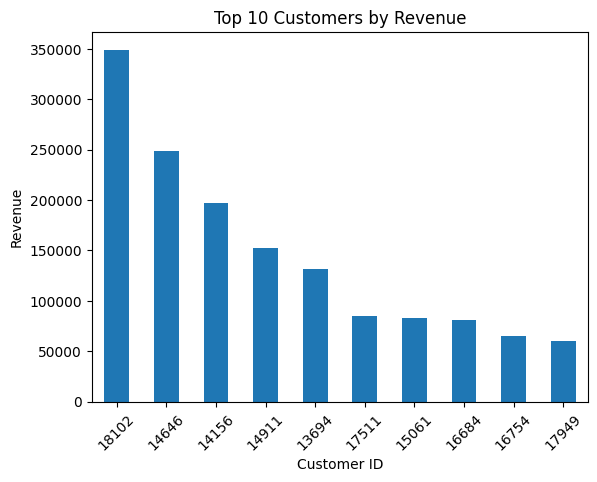

In [110]:
#Visualization
customer_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### Observation
#### Observation 1 : Customer 18102 generated the highest revenue among all customers.
#### Observation 2 : Revenue decreases gradually from the first customer to the tenth customer.
#### Observation 3 : Customer revenue is concentrated among a few customers rather than being equally distributed.

### Business Insight
#### Business Insight 1 : The business has a few high-value customers who contribute significantly to revenue.
#### Business Insight 2 : These customers should be retained through loyalty programs and personalized offers.
#### Business Insight 3 : Losing top customers may negatively impact overall business revenue.

2. Which customers place the highest number of orders?

In [111]:
#Calculate Orders per Customer
customers_orders = df.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False)
customers_orders.head(10)

Customer ID
14911.0    205
17850.0    155
12748.0    144
15311.0    121
13089.0    109
14606.0    102
14156.0    102
13694.0     94
17841.0     91
18102.0     89
Name: Invoice, dtype: int64

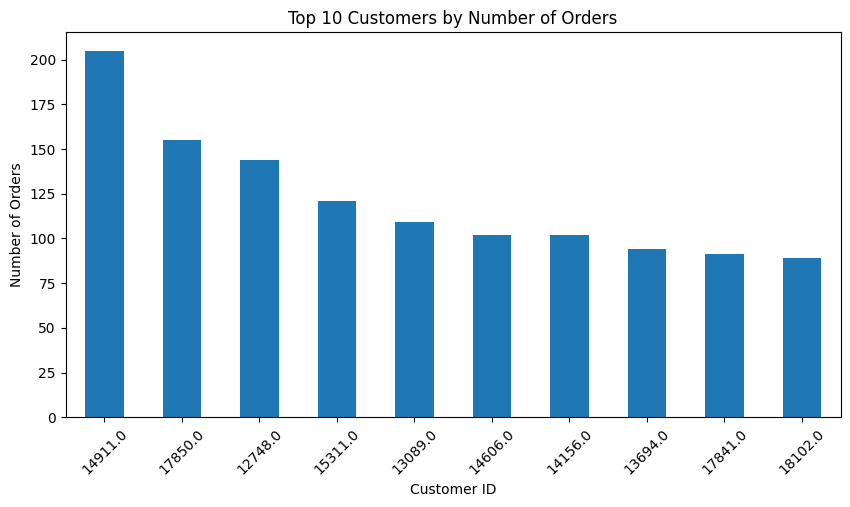

In [112]:
#Visualization
customers_orders.head(10).plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Customers by Number of Orders')
plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

### Observation
#### Observation 1 : Customer 14911 placed the highest number of orders (around 205 orders).
#### Observation 2 : Customer 17850 and 12748 are the next most frequent buyers.
#### Observation 3 : The number of orders gradually decreases across the remaining top customers.
#### Observation 4 : Customer 18102, who was the highest revenue customer, appears near the bottom of this chart with fewer orders.

### Business Insights
#### Business Insight 1 : Customers who place the most orders are not necessarily the customers who generate the highest revenue.
#### Business Insight 2 : Some customers buy frequently but spend smaller amounts per order.
#### Business Insight 3 : Other customers place fewer orders but make high-value purchases.
#### Business Insight 4 : The business should create separate strategies for:
####   Frequent customers → loyalty rewards, membership programs.
####   High-spending customers → personalized offers and premium services.

3 How can we group customers based on the revenue they generate?

In [113]:
df['Customer ID'] = df['Customer ID'].replace(0, np.nan)

In [114]:
df['Customer ID'].isnull().sum()

103815

In [115]:
#Revenue Per Customer
customer_revenue = df.groupby('Customer ID')['Revenue'].sum()
customer_revenue.head()

Customer ID
12346.0     372.86
12347.0    1323.32
12348.0     222.16
12349.0    2671.14
12351.0     300.93
Name: Revenue, dtype: float64

In [116]:
#Create Segments
customer_segments = pd.qcut(
    customer_revenue,
    q=3,
    labels=['Low Value','Medium Value','High Value']
)
customer_segments.head()

Customer ID
12346.0     Low Value
12347.0    High Value
12348.0     Low Value
12349.0    High Value
12351.0     Low Value
Name: Revenue, dtype: category
Categories (3, object): ['Low Value' < 'Medium Value' < 'High Value']

In [117]:
#Count Customers in Each Segment
segment_count = customer_segments.value_counts()
segment_count

Revenue
Low Value       1438
Medium Value    1437
High Value      1437
Name: count, dtype: int64

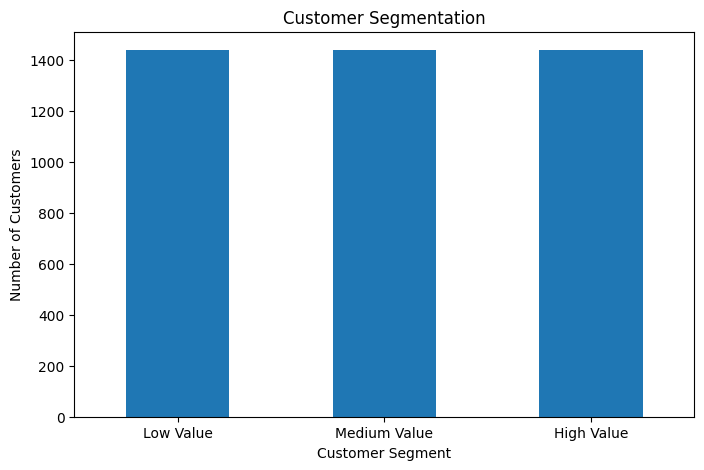

In [118]:
#Visualization
segment_count.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Customer Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

In [119]:
#Revenue Contribution by Segment
segment_revenue = customer_revenue.groupby(customer_segments).sum()
segment_revenue

C:\Users\aishw\AppData\Local\Temp\ipykernel_1176\239029632.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = customer_revenue.groupby(customer_segments).sum()


Revenue
Low Value        315782.991
Medium Value    1067791.702
High Value      7414659.051
Name: Revenue, dtype: float64

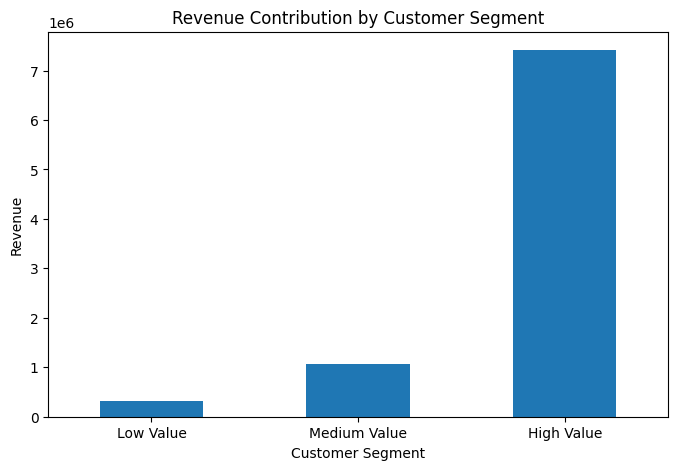

In [120]:
#Visualization
segment_revenue.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Revenue Contribution by Customer Segment')

plt.xlabel('Customer Segment')
plt.ylabel('Revenue')

plt.xticks(rotation=0)

plt.show()

### OBSERVATION 
##### 1. High Value customers contribute the majority of revenue.

### BUSINESS INSIGHT
#### 1. Retaining High Value customers should be a business priority because they generate most of the revenue.

4. RFM Analysis

In [121]:
df['InvoiceDate'].min()

Timestamp('2009-12-01 07:45:00')

In [122]:
df['InvoiceDate'].max()

Timestamp('2010-12-09 20:01:00')

In [123]:
df.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName,Day,DayName,Hour,YearMonth,Weekday,Quarter,Price_Category
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday,7,2009-12,Tuesday,4,Medium Price


In [124]:
# Creating RFM Table
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate' : lambda x : (df['InvoiceDate'].max() - x.max()),
    'Invoice' : 'nunique',
    'Revenue' : sum
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

C:\Users\aishw\AppData\Local\Temp\ipykernel_1176\4169169526.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  rfm = df.groupby('Customer ID').agg({


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,164 days 06:08:00,11,372.86
12347.0,2 days 05:04:00,2,1323.32
12348.0,73 days 05:02:00,1,222.16
12349.0,42 days 11:38:00,3,2671.14
12351.0,10 days 04:38:00,1,300.93


In [125]:
#creating scores
rfm['R_Score'] = pd.qcut(rfm['Recency'],q=5,labels=[1,2,3,4,5])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),q=5,labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],q=5,labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346.0,164 days 06:08:00,11,372.86,4,5,2
12347.0,2 days 05:04:00,2,1323.32,1,2,4
12348.0,73 days 05:02:00,1,222.16,4,1,1
12349.0,42 days 11:38:00,3,2671.14,3,3,5
12351.0,10 days 04:38:00,1,300.93,1,1,2


In [126]:
rfm['Frequency'].describe()

count    4312.000000
mean        4.455705
std         8.170213
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       205.000000
Name: Frequency, dtype: float64

In [127]:
rfm['Frequency'].value_counts().head(10)

Frequency
1     1419
2      810
3      525
4      378
5      238
6      192
7      157
8      109
9       80
10      69
Name: count, dtype: int64

In [128]:
#create the combined RFM Score
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,164 days 06:08:00,11,372.86,4,5,2,452
12347.0,2 days 05:04:00,2,1323.32,1,2,4,124
12348.0,73 days 05:02:00,1,222.16,4,1,1,411
12349.0,42 days 11:38:00,3,2671.14,3,3,5,335
12351.0,10 days 04:38:00,1,300.93,1,1,2,112


In [129]:
#creating over all Total_RFM_Score
rfm['Total_RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Total_RFM_Score
Customer ID,,,,,,,,
12346.0,164 days 06:08:00,11,372.86,4,5,2,452,11
12347.0,2 days 05:04:00,2,1323.32,1,2,4,124,7
12348.0,73 days 05:02:00,1,222.16,4,1,1,411,6
12349.0,42 days 11:38:00,3,2671.14,3,3,5,335,11
12351.0,10 days 04:38:00,1,300.93,1,1,2,112,4


In [130]:
#Create Customer Segments
rfm['Customer_segment'] = pd.cut(
    rfm['Total_RFM_Score'],
    bins=[0,5,10,15],
    labels=['Lost Customers','Potential Customers','Champions']
)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Total_RFM_Score,Customer_segment
Customer ID,,,,,,,,,
12346.0,164 days 06:08:00,11,372.86,4,5,2,452,11,Champions
12347.0,2 days 05:04:00,2,1323.32,1,2,4,124,7,Potential Customers
12348.0,73 days 05:02:00,1,222.16,4,1,1,411,6,Potential Customers
12349.0,42 days 11:38:00,3,2671.14,3,3,5,335,11,Champions
12351.0,10 days 04:38:00,1,300.93,1,1,2,112,4,Lost Customers


In [131]:
#Count Customers in Each Segment
segment_count = rfm['Customer_segment'].value_counts()
segment_count.head()

Customer_segment
Potential Customers    2686
Champions              1335
Lost Customers          291
Name: count, dtype: int64

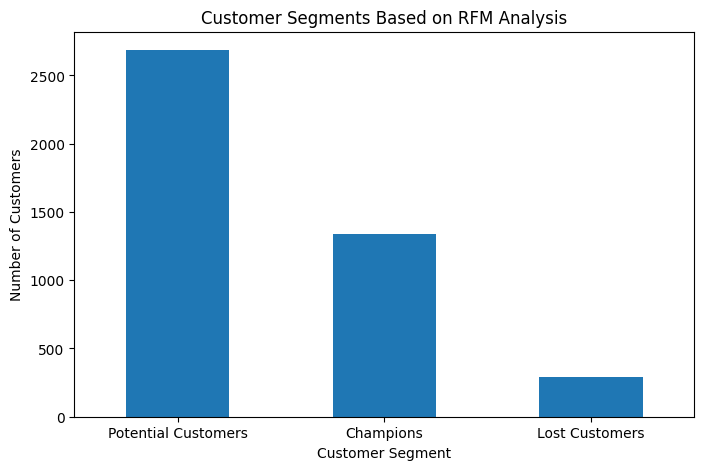

In [132]:
#Visualization
segment_count.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Customer Segments Based on RFM Analysis')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

### OBSERVATION 
##### 1. Potential Customers are the largest segment (~2700 customers).
##### 2. Champions are the second largest segment (~1300 customers).
##### 3. Lost Customers are very few (~300 customers).

### BUSINESS INSIGHT
#### 1. The business has a strong customer base, as most customers are either Potential Customers or Champions.
#### 2. Potential Customers represent the biggest growth opportunity. With targeted offers, loyalty programs, and personalized recommendations, many of them can be converted into Champions.
#### 3. Champions should be retained through exclusive benefits, early access to products, and reward programs.
#### 4. The low number of Lost Customers suggests good customer retention overall.

5. #5  Churn Analysis - Which customers are inactive and at risk of leaving?

In [133]:
rfm['churn_status'] = rfm['Recency'].apply(
    lambda x: 'churned' if x.days > 90 else 'Active'
)

In [134]:
#
churn_count = rfm['churn_status'].value_counts()
churn_count

churn_status
Active     2885
churned    1427
Name: count, dtype: int64

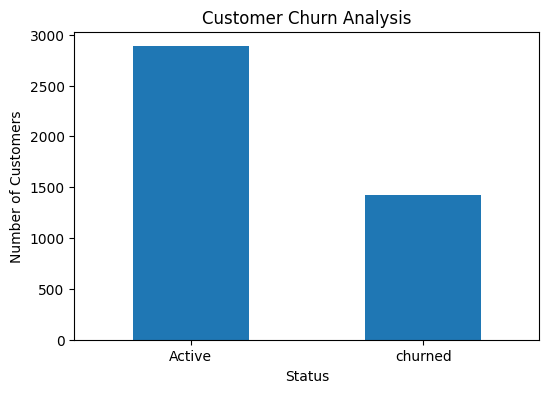

In [135]:
#Visualization
churn_count.plot(
    kind='bar',
    figsize=(6,4)
)
plt.title('Customer Churn Analysis')

plt.xlabel('Status')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

### OBSERVATION 
##### 1. Around 2900 customers are Active.
##### 2. Around 1400 customers are Churned.
##### 3. Active customers are almost 2 times the churned customers.

### BUSINESS INSIGHT
#### 1. The business has retained a majority of its customers.
#### 2. However, around one-third of customers have become inactive, which represents a significant revenue recovery opportunity.
#### 3. Targeted email campaigns, discounts, loyalty rewards, or personalized product recommendations can be used to re-engage churned customers.
#### 4. Reducing churn by even a small percentage can significantly increase future revenue.

In [136]:
rfm.head(2)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Total_RFM_Score,Customer_segment,churn_status
Customer ID,,,,,,,,,,
12346.0,164 days 06:08:00,11,372.86,4,5,2,452,11,Champions,churned
12347.0,2 days 05:04:00,2,1323.32,1,2,4,124,7,Potential Customers,Active


In [137]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score',
       'RFM_Score', 'Total_RFM_Score', 'Customer_segment', 'churn_status'],
      dtype='object')

In [138]:
rfm=rfm.reset_index()

In [139]:
rfm.to_csv('Customer_RFM.csv',index=False)

### Exporting to CSV file

In [140]:
df.to_csv('RetailSales_Cleaned.csv',index=False)

In [141]:
df.dtypes

Invoice                   object
StockCode                 object
Description               object
Quantity                   int64
InvoiceDate       datetime64[ns]
Price                    float64
Customer ID              float64
Country                   object
Revenue                  float64
Year                       int32
Month                      int32
MonthName                 object
Day                        int32
DayName                   object
Hour                       int32
YearMonth              period[M]
Weekday                   object
Quarter                    int32
Price_Category          category
dtype: object

In [142]:
df['Customer ID'].isna().sum()

103815

In [143]:
df['YearMonth'].nunique()

13

In [144]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month',
       'MonthName', 'Day', 'DayName', 'Hour', 'YearMonth', 'Weekday',
       'Quarter', 'Price_Category'],
      dtype='object')